# Project 02: Model Interpretability
**Objective:** A diagnostic notebook designed to evaluate feature attribution, structural stability, and out-of-sample predictive dependence for the classification pipeline developed in `01_return_classifier`

In [1]:
import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.base import clone
import matplotlib.pyplot as plt

c:\Users\hp\Development\portfolio-quant-ds\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
screening_dataset = pd.read_parquet("../data/screener_results.parquet")

sector_map = {("NVDA", "MSFT", "MSTR"): "Tech", ("JPM", "BAC", "MS"): "Financials", 
              ("LLY", "JNJ", "ABBV"): "Healthcare", ("XOM", "CVX", "COP"): "Energy",
              ("PG", "KO", "PEP"): "Consumer Staples", "SPY": "Market"}

flat_sector_map = {ticker: sector for tickers, sector in sector_map.items() for ticker in (tickers if isinstance(tickers, tuple) else [tickers])}

# Extract the End-of-Month (EoM) snapshots and aggregate the investable universe
monthly_portfolio = (
    screening_dataset
    .groupby(['ticker', pd.Grouper(key='date', freq='ME')]).last() # Isolate the last trading day per month
    .reset_index()
)

assert monthly_portfolio.groupby('ticker')['date'].apply(lambda s: s.is_monotonic_increasing).all(), "Non monotone dates in at least one ticker — shift(-1) would calculate the wrong forward return"

# Adding of the column containing the sector linked to the ticker
monthly_portfolio["gics_sector"] = monthly_portfolio["ticker"].map(flat_sector_map)
# Computation of the column representing the return at one month
monthly_portfolio["forward_1m_return"] = monthly_portfolio.groupby("ticker")["close"].shift(-1) / monthly_portfolio["close"] -1
# Dropping of NaN values for cold start and last month of the dataset for every ticker
monthly_portfolio = monthly_portfolio.dropna().reset_index(drop=True)
# Creation of target variable: 1 if the forward return is positive, 0 otherwise
monthly_portfolio["target_class"] = (monthly_portfolio["forward_1m_return"] > 0).astype(int)

assert monthly_portfolio["forward_1m_return"].isna().sum() == 0, "Leakage/Null error: Found NaNs in target"
assert set(monthly_portfolio["target_class"].unique()).issubset({0, 1}), "Target class must be binary"

In [3]:
# Selection of feature and target columns
feature_cols = ["momentum_126d", "rolling_vol_63d", "current_dd_126d", "gics_sector"]
target_col = "target_class"
# Creation of the train dataset
train_dataset = monthly_portfolio[(monthly_portfolio["date"] <= "2024-06-30") & (monthly_portfolio["ticker"] != "SPY")].reset_index(drop=True)
X_train = train_dataset[feature_cols]
y_train = train_dataset[target_col]
# Creation of the test dataset
test_dataset = monthly_portfolio[(monthly_portfolio["date"] > "2024-06-30") & (monthly_portfolio["ticker"] != "SPY")].reset_index(drop=True)
X_test = test_dataset[feature_cols]
y_test = test_dataset[target_col]
# Copy of date and ticker for analysis
test_metadata = test_dataset[["date", "ticker"]].copy()

In [4]:
numeric_features = ["momentum_126d", "rolling_vol_63d", "current_dd_126d"]
categorical_features = ["gics_sector"]
# Transformation routing
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline assembling
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            l1_ratio=0,             # Ridge regularization to handle collinearity post one-hot (same as penalty='l2')
            C=10.0,                 # Inverse regularization strength
            solver='lbfgs',         # Quasi-Newton optimization algorithm
            max_iter=1000,          # Guarantees convergence on scaled features
            random_state=42,        # Strict numerical reproducibility
            class_weight='balanced' # Rebalancing of weights
            )
        )
    ]
)
# Pipeline fit
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [5]:
acc = accuracy_score(y_test, y_pred)
recall_down = recall_score(y_test, y_pred, pos_label=0) 
recall_up = recall_score(y_test, y_pred, pos_label=1)  

# Gate metrics from published README
assert np.isclose(acc, 0.49, atol=0.01), f"Accuracy mismatch: {acc}"
assert np.isclose(recall_down, 0.55, atol=0.01), f"Recall Down mismatch: {recall_down}"
assert np.isclose(recall_up, 0.43, atol=0.01), f"Recall Up mismatch: {recall_up}"
print("Reproducibility gate passed. Same metrics of README.")

Reproducibility gate passed. Same metrics of README.


### Dataset & Pipeline Reconstruction

The initial cells reconstruct the exact temporal split and classification pipeline from `01_return_classifier`. By successfully validating the out-of-sample Test metrics against the published README, we formally pass the reproducibility gate, ensuring the interpretability layer audits the correct model state.

In [6]:
preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]
reference_coef = classifier.coef_.copy()  # guard: the full-Train model must never be refitted below
feature_names = preprocessor.get_feature_names_out()
feature_coeff = classifier.coef_[0]
abs_values = np.abs(feature_coeff)

standardized_coeff = pd.DataFrame({"Feature_Names": feature_names, "Feature_Coefficients": feature_coeff, "Absolute_Values": abs_values})
standardized_coeff.sort_values(by =["Absolute_Values"], inplace=True, ascending=False)
display(standardized_coeff)

,Feature_Names,Feature_Coefficients,Absolute_Values
7,cat__gics_sector_Tech,0.631990,0.631990
4,cat__gics_sector_Energy,-0.449206,0.449206
2,num__current_dd_126d,-0.388786,0.388786
1,num__rolling_vol_63d,-0.321609,0.321609
5,cat__gics_sector_Financials,-0.184948,0.184948
3,cat__gics_sector_Consumer Staples,0.079332,0.079332
6,cat__gics_sector_Healthcare,-0.063344,0.063344
0,num__momentum_126d,0.027071,0.027071


### Standardized Coefficients (Structural Inspection)

Standardized coefficients describe the weights of the fitted model. Numeric coefficients are expressed per standard deviation, whereas sector coefficients are 0/1 dummy shifts, so their magnitudes are not directly comparable: the mean |SHAP| ranking in the attribution section is the like-for-like view.

Momentum receives almost no weight (+0.03), even though it is one of the screener's three rules.

In [7]:
perm = permutation_importance(pipeline, X_test, y_test, n_repeats=30, random_state=42, scoring="accuracy")
imp_mean = perm.importances_mean
imp_std = perm.importances_std

importances = pd.DataFrame({"Feature_Names": feature_cols, "Importances_Mean": imp_mean, "Importances_Std": imp_std})
importances["Mean_over_Std"] = importances["Importances_Mean"] / importances["Importances_Std"]
display(importances.round(3))

,Feature_Names,Importances_Mean,Importances_Std,Mean_over_Std
0,momentum_126d,0.002,0.016,0.113
1,rolling_vol_63d,-0.022,0.025,-0.884
2,current_dd_126d,0.005,0.044,0.110
3,gics_sector,0.004,0.043,0.094


In [8]:
def perm_importance_group(model, X, y, metric, n_repeats, seed, features_to_test):
    rng = np.random.default_rng(seed)
    X_df = X.copy()
    y_preds = model.predict(X_df)
    base_accuracy = metric(y, y_preds)
    mean_for_feature = []
    std_for_feature = []
    for f in features_to_test:
        cols = f if isinstance(f,list) else [f]
        original_values = X_df[cols].to_numpy(copy=True)
        importance=[]
        for i in range(n_repeats):
            shuffled_idx = rng.permutation(len(X_df))
            X_df[cols] = original_values[shuffled_idx, :]
            y_preds_shuffle = model.predict(X_df)
            curr_accuracy = metric(y, y_preds_shuffle)
            importance.append(base_accuracy - curr_accuracy)
        mean_for_feature.append(np.mean(importance))
        std_for_feature.append(np.std(importance))
        X_df[cols] = original_values
    return mean_for_feature, std_for_feature

In [9]:
column_group = ["momentum_126d", "rolling_vol_63d", "current_dd_126d"]

group_mean, group_std = perm_importance_group(pipeline, X_test, y_test, accuracy_score, 30, 42, [column_group, "gics_sector"])

group_importances = pd.DataFrame({"Feature_Names": ["Numeric_group", "Sector"], "Importances_Mean": group_mean, "Importances_Std": group_std})
group_importances["Mean_over_Std"] = group_importances["Importances_Mean"] / group_importances["Importances_Std"]
display(group_importances.round(3))


,Feature_Names,Importances_Mean,Importances_Std,Mean_over_Std
0,Numeric_group,-0.031,0.045,-0.686
1,Sector,-0.015,0.039,-0.384


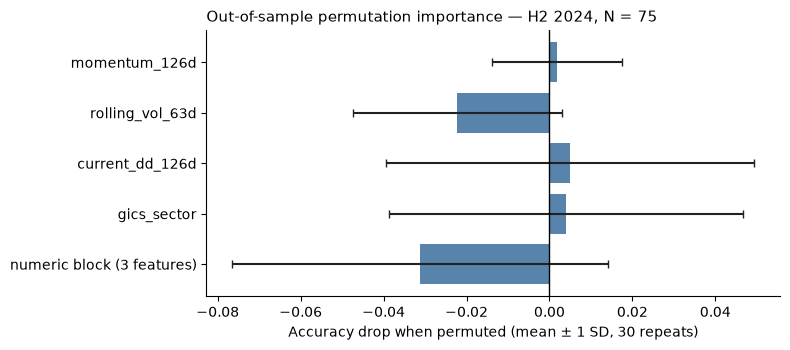

In [10]:
# Main figure: out-of-sample permutation importance, mean ± 1 SD
plot_df = pd.concat([importances, group_importances.iloc[[0]]], ignore_index=True)
labels = ["momentum_126d", "rolling_vol_63d", "current_dd_126d", "gics_sector", "numeric block (3 features)"]
ypos = np.arange(len(plot_df))[::-1]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(ypos, plot_df["Importances_Mean"], xerr=plot_df["Importances_Std"], color="#3B6E9C", alpha=0.85, ecolor="#222222", capsize=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(ypos, labels)
ax.set_xlabel("Accuracy drop when permuted (mean ± 1 SD, 30 repeats)")
ax.set_title("Out-of-sample permutation importance — H2 2024, N = 75", loc="left", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Out-of-Sample Permutation Importance (Agnostic Inspection)

The cells above compute the out-of-sample permutation importance, evaluating both individual features (via `scikit-learn`) and the aggregated quantitative block (via a custom function that applies the same shuffle to every column of the block, preserving intra-block correlation). Each feature is permuted 30 times on the H2 2024 test set and the accuracy drop is reported as mean ± 1 SD.

Permuting features, individually or as a block, does not degrade test accuracy beyond noise: every mean lies within one standard deviation of zero (`Mean_over_Std` between −0.9 and +0.1; $N = 75$, non-independent observations). With a standard deviation of about 0.04, the test can only exclude dependence above roughly 8 accuracy points: absence of evidence, not evidence of absence.

In [11]:
# Extraction of the transformed train and test matrices
X_test_trans = preprocessor.transform(X_test)
X_train_trans = preprocessor.transform(X_train)
# The explained model must be the full-Train reference fit
assert classifier.coef_.shape == reference_coef.shape and np.allclose(classifier.coef_, reference_coef), "Classifier state differs from the reference fit (stale refit?)"
# Explicit background = full Train set (the default subsamples to 100 rows and shifts the baseline)
masker = shap.maskers.Independent(X_train_trans, max_samples=len(X_train_trans))
explainer = shap.LinearExplainer(classifier, masker, feature_names=feature_names)  # Independent masker = interventional
shap_explanation = explainer(X_test_trans)
# Reconstruction of values to verify additivity
expected_value = explainer.expected_value
reconstructed_margin = expected_value + shap_explanation.values.sum(axis=1)
actual_margin = classifier.decision_function(X_test_trans)
# Assert to confirm the additivity value
assert np.allclose(reconstructed_margin, actual_margin), "SHAP Additivity check failed: reconstructed margin does not match decision_function"
print(f"Additivity assertion passed: expected_value + sum(SHAP) == decision_function across all {len(X_test_trans)} test samples.")

Additivity assertion passed: expected_value + sum(SHAP) == decision_function across all 75 test samples.


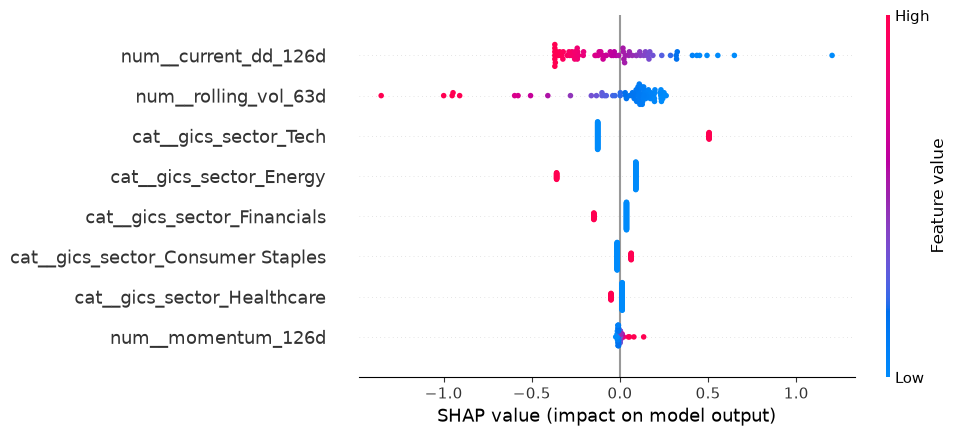

ML=1 | Screener=1: COP 2024-08-31


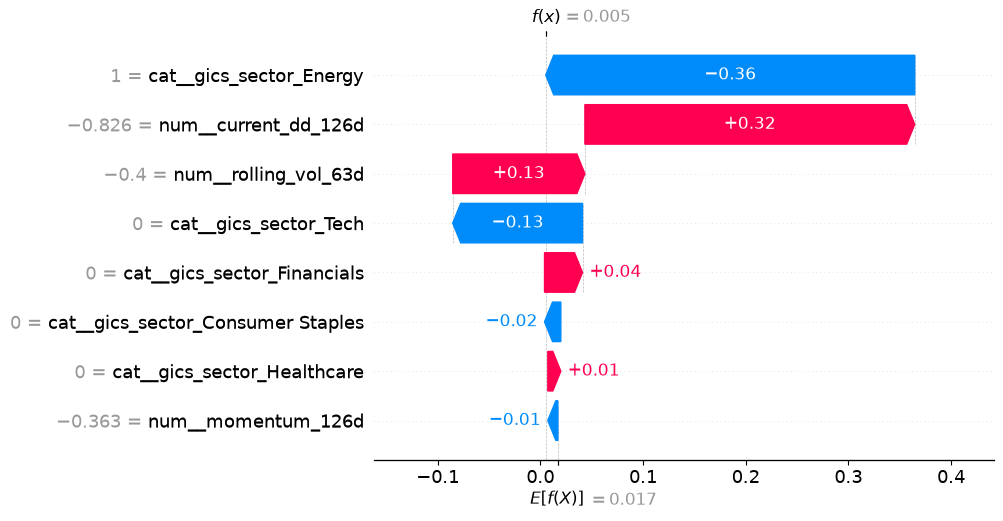

ML=0 | Screener=1: ABBV 2024-09-30


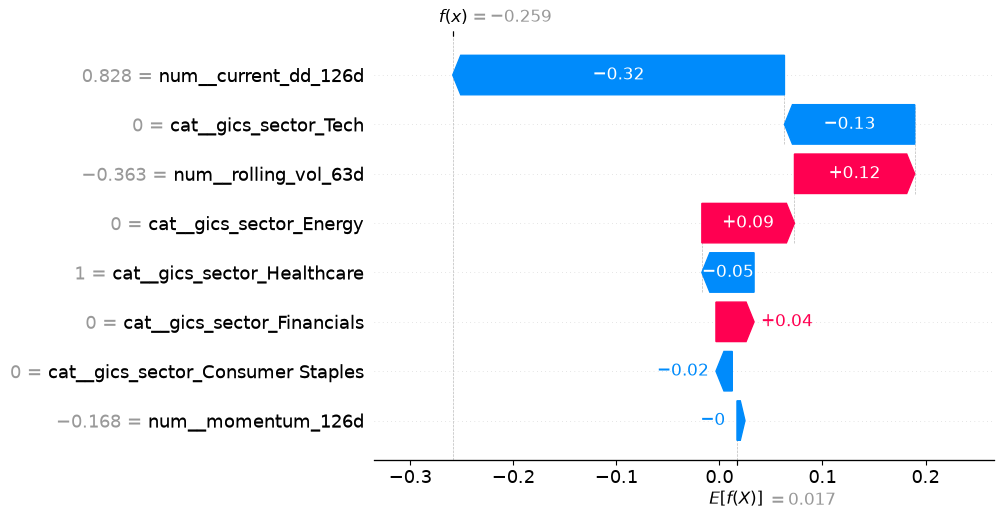

,n,dd_raw,dd_SHAP,vol_raw,vol_SHAP
ML=0 | Scr=0,27,-0.048,-0.124,0.327,-0.080
ML=0 | Scr=1,15,-0.017,-0.281,0.182,0.154
ML=1 | Scr=0,18,-0.132,0.303,0.398,-0.194
ML=1 | Scr=1,15,-0.069,-0.022,0.156,0.196


,mean_abs_SHAP
num__current_dd_126d,0.232
num__rolling_vol_63d,0.215
cat__gics_sector_Tech,0.202
cat__gics_sector_Energy,0.144
cat__gics_sector_Financials,0.059
cat__gics_sector_Consumer Staples,0.025
cat__gics_sector_Healthcare,0.020
num__momentum_126d,0.012


In [12]:
# Construction of the dataset with the comparisons between screener and ML
comparison = test_metadata.copy()
comparison["actual_target"] = y_test.values
comparison["ml_signal"] = y_pred
comparison["screener_signal"] = test_dataset["is_investable"].astype(int).values

shap.plots.beeswarm(shap_explanation)

# Illustrative cases: first row of each quadrant (rows are sorted by ticker, so illustrative, not representative)
agreement_idx = comparison[(comparison["ml_signal"] == 1) & (comparison["screener_signal"] == 1)].index[0]
divergence_idx = comparison[(comparison["ml_signal"] == 0) & (comparison["screener_signal"] == 1)].index[0]
for label, idx in [("ML=1 | Screener=1", agreement_idx), ("ML=0 | Screener=1", divergence_idx)]:
    print(f"{label}: {comparison.loc[idx, 'ticker']} {comparison.loc[idx, 'date'].date()}")
    shap.plots.waterfall(shap_explanation[idx])

# Where ML and screener disagree: drawdown and volatility, raw values vs SHAP contributions
quadrant = (comparison["ml_signal"].map({1: "ML=1", 0: "ML=0"}) + " | "
            + comparison["screener_signal"].map({1: "Scr=1", 0: "Scr=0"}))
shap_df = pd.DataFrame(shap_explanation.values, columns=feature_names)
quadrant_summary = pd.DataFrame({
    "n": quadrant.value_counts(),
    "dd_raw": test_dataset.groupby(quadrant.values)["current_dd_126d"].mean(),
    "dd_SHAP": shap_df.groupby(quadrant.values)["num__current_dd_126d"].mean(),
    "vol_raw": test_dataset.groupby(quadrant.values)["rolling_vol_63d"].mean(),
    "vol_SHAP": shap_df.groupby(quadrant.values)["num__rolling_vol_63d"].mean(),
}).round(3).sort_index()
display(quadrant_summary)

# Like-for-like attribution scale (dummies and standardized numerics are not comparable as raw coefficients)
display(pd.Series(np.abs(shap_explanation.values).mean(axis=0), index=feature_names, name="mean_abs_SHAP")
        .sort_values(ascending=False).round(3).to_frame())

In [13]:
# Context checks: base rates by sector and marginal correlation with the target
base_rates = pd.DataFrame({
    "train_up_rate": train_dataset.groupby("gics_sector")[target_col].mean(),
    "test_up_rate": test_dataset.groupby("gics_sector")[target_col].mean(),
})
base_rates.loc["ALL"] = [train_dataset[target_col].mean(), test_dataset[target_col].mean()]
display(base_rates.round(2))

marginal_corr = pd.DataFrame({
    "train": train_dataset[numeric_features + [target_col]].corr()[target_col],
    "test": test_dataset[numeric_features + [target_col]].corr()[target_col],
}).drop(target_col)
display(marginal_corr.round(3))

,train_up_rate,test_up_rate
gics_sector,,
Consumer Staples,0.62,0.33
Energy,0.50,0.40
Financials,0.55,0.67
Healthcare,0.58,0.33
Tech,0.67,0.60
ALL,0.58,0.47


,train,test
momentum_126d,-0.029,-0.025
rolling_vol_63d,0.016,0.113
current_dd_126d,-0.118,-0.097


### Local Attribution (SHAP Values)

SHAP decomposes each test prediction into additive log-odds contributions. For a linear model this equals coefficient × (standardized value − background mean), so it adds per-observation detail rather than new information. On a like-for-like scale, drawdown, volatility and the `Tech` dummy carry similar attribution (mean |SHAP| ≈ 0.20–0.23 each); momentum is negligible (≈ 0.01).

The quadrant table shows where the model and the screener disagree. In the 15 cases where the screener approves and the model rejects, assets sit close to their 6-month high (mean drawdown −1.7%) and receive a strongly negative drawdown contribution (−0.28). In the 18 cases where the model approves and the screener rejects, assets are in deep drawdown (−13.2%) and receive a positive contribution (+0.30). The disagreement is largely a mirror image on drawdown: the fitted model leans contrarian where the screener excludes deep drawdowns.

Two cautions. Signs are partial effects: the marginal correlation of volatility with the target is close to zero (+0.02 in Train, +0.11 in Test), so its negative weight emerges only after conditioning on momentum and drawdown. The drawdown sign, by contrast, is also present marginally in both periods (−0.12 and −0.10), although small and not significant on 75 observations. With AUC close to 0.5, these attributions describe the fitted model, not a validated market effect.

In [ ]:
def panel_walk_forward_split(dates, n_splits=4, test_size_months= 3):
    unique_dates = np.unique(dates)
    n_total = len(unique_dates)
    for i in reversed(range(n_splits)):
        test_start = n_total - test_size_months * (i + 1)
        test_end = n_total - test_size_months * i
        
        test_fold = unique_dates[test_start:test_end]
        train_fold = unique_dates[:test_start]
        train_indices = np.where(np.isin(dates, train_fold))[0]
        test_indices = np.where(np.isin(dates, test_fold))[0]
        yield train_indices, test_indices

In [ ]:
fold_coefficients = []

for fold_idx, (train_idx, test_idx) in enumerate(panel_walk_forward_split(train_dataset["date"])):
    # Extract training dataset
    train_dataset_fold = train_dataset.iloc[train_idx]
    # Extracting X_train and y_train for every fold
    X_train_fold = train_dataset_fold[feature_cols]
    y_train_fold = train_dataset_fold[target_col]
    # Clone: the reference pipeline used by the SHAP and permutation cells must never be refitted
    fold_pipeline = clone(pipeline).fit(X_train_fold, y_train_fold)
    fold_names = fold_pipeline.named_steps["preprocessor"].get_feature_names_out()
    fold_coefficients.append(dict(zip(fold_names, fold_pipeline.named_steps["classifier"].coef_[0])))

assert classifier.coef_.shape == reference_coef.shape and np.allclose(classifier.coef_, reference_coef), "Reference pipeline was mutated by the fold loop"
fold_df = pd.DataFrame(fold_coefficients).rename_axis("fold")
display(fold_df.round(3).T)

fold,0,1,2,3
num__momentum_126d,0.656,0.310,0.234,0.043
num__rolling_vol_63d,-0.697,-0.145,-0.289,-0.319
num__current_dd_126d,-1.136,-0.685,-0.628,-0.424
cat__gics_sector_Consumer Staples,0.205,0.238,0.111,0.066
cat__gics_sector_Energy,-0.688,-0.022,-0.437,-0.302
cat__gics_sector_Financials,-0.219,-0.467,-0.249,-0.349
cat__gics_sector_Healthcare,-0.386,-0.092,0.002,-0.090
cat__gics_sector_Tech,1.154,0.356,0.591,0.691


### Structural Stability Across Walk-Forward Folds

The linear pipeline is refitted on each of the 4 expanding walk-forward training windows to observe how the fitted weights move.

Coefficient signs are consistent across folds, but the windows are nested (each contains the previous one), so agreement is partly mechanical. Magnitudes are not stable: the momentum weight falls from 0.66 to 0.04 and the drawdown weight from −1.14 to −0.42. Stability of an estimate is not evidence of predictive validity.

In [16]:
# Preprocessor for the challenger
preprocessor_challenger = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
# Challenger pipeline assembling
pipeline_challenger = Pipeline(
    steps=[
        ('preprocessor', preprocessor_challenger),
        ('classifier', HistGradientBoostingClassifier(
            max_iter=100,
            max_depth=3,
            class_weight='balanced',
            random_state=42
        )
        )
    ]
)

In [17]:
F1_score = []
F1_score_challenger = []
roc_auc = []
roc_auc_challenger = []
roc_auc_train_challenger = []

for fold_idx, (train_idx, test_idx) in enumerate(panel_walk_forward_split(train_dataset["date"])):

    # Extract training and test dataset
    train_dataset_fold = train_dataset.iloc[train_idx]
    test_dataset_fold = train_dataset.iloc[test_idx]
    # Extracting X_train and y_train for every fold
    X_train_fold = train_dataset_fold[feature_cols]
    y_train_fold = train_dataset_fold[target_col]
    # Extracting X_test and y_test for every fold
    X_test_fold = test_dataset_fold[feature_cols]
    y_test_fold = test_dataset_fold[target_col]
    # Cloning the pipeline to avoid shared state
    fold_pipeline = clone(pipeline)
    fold_challenger = clone(pipeline_challenger)
    # Pipelines fit
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fold_challenger.fit(X_train_fold, y_train_fold)
    # Pipelines predictions on test set
    y_pred_base = fold_pipeline.predict(X_test_fold)
    y_pred_challenger =fold_challenger.predict(X_test_fold)
    # Continuous probability for ROC-AUC computation (class 1)
    y_prob_base = fold_pipeline.predict_proba(X_test_fold)[:, 1]
    y_prob_challenger = fold_challenger.predict_proba(X_test_fold)[:, 1]
    y_prob_train_challenger = fold_challenger.predict_proba(X_train_fold)[:, 1]
    # Computation of F1 scores and roc-auc
    F1_score.append(f1_score(y_test_fold, y_pred_base, average='macro'))
    F1_score_challenger.append(f1_score(y_test_fold, y_pred_challenger, average='macro'))
    roc_auc.append(roc_auc_score(y_test_fold, y_prob_base))
    roc_auc_challenger.append(roc_auc_score(y_test_fold, y_prob_challenger))
    roc_auc_train_challenger.append(roc_auc_score(y_train_fold, y_prob_train_challenger))

results = pd.DataFrame({"F1_score": F1_score, 
                        "F1_score Challenger": F1_score_challenger,
                        "ROC-AUC": roc_auc, 
                        "ROC-AUC Challenger": roc_auc_challenger, 
                        "ROC-AUC Train Challenger": roc_auc_train_challenger})
results.loc['Mean'] = results.mean()
display(results.round(3))

,F1_score,F1_score Challenger,ROC-AUC,ROC-AUC Challenger,ROC-AUC Train Challenger
0,0.389,0.453,0.466,0.452,0.935
1,0.498,0.416,0.518,0.506,0.919
2,0.377,0.408,0.561,0.402,0.918
3,0.464,0.389,0.517,0.420,0.917
Mean,0.432,0.417,0.515,0.445,0.922


In [18]:
# ROC-AUC on the held-out H2 2024 test, and pooled walk-forward AUC with a month-clustered bootstrap
final_base = clone(pipeline).fit(X_train, y_train)
final_challenger = clone(pipeline_challenger).fit(X_train, y_train)
heldout_auc = pd.DataFrame({
    "AUC_train": [roc_auc_score(y_train, m.predict_proba(X_train)[:, 1]) for m in (final_base, final_challenger)],
    "AUC_test_H2_2024": [roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]) for m in (final_base, final_challenger)],
}, index=["Logistic (tuned)", "Gradient Boosting"])
display(heldout_auc.round(3))

oos_parts = []
for train_idx, test_idx in panel_walk_forward_split(train_dataset["date"]):
    fold_train, fold_test = train_dataset.iloc[train_idx], train_dataset.iloc[test_idx]
    part = fold_test[["date", target_col]].copy()
    part["p_base"] = clone(pipeline).fit(fold_train[feature_cols], fold_train[target_col]).predict_proba(fold_test[feature_cols])[:, 1]
    part["p_challenger"] = clone(pipeline_challenger).fit(fold_train[feature_cols], fold_train[target_col]).predict_proba(fold_test[feature_cols])[:, 1]
    oos_parts.append(part)
oos = pd.concat(oos_parts, ignore_index=True)

# Bootstrap resampling whole months (12 clusters) to respect the cross-sectional dependence within a month
month_groups = [g for _, g in oos.groupby("date")]
rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    sample = pd.concat([month_groups[i] for i in rng.integers(0, len(month_groups), len(month_groups))])
    if sample[target_col].nunique() == 2:
        boot.append((roc_auc_score(sample[target_col], sample["p_base"]), roc_auc_score(sample[target_col], sample["p_challenger"])))
boot = np.array(boot)

pooled = pd.DataFrame({
    "pooled_AUC": [roc_auc_score(oos[target_col], oos["p_base"]), roc_auc_score(oos[target_col], oos["p_challenger"])],
    "CI95_low": np.percentile(boot, 2.5, axis=0),
    "CI95_high": np.percentile(boot, 97.5, axis=0),
}, index=["Logistic (tuned)", "Gradient Boosting"])
display(pooled.round(3))
diff_ci = np.percentile(boot[:, 0] - boot[:, 1], [2.5, 97.5])
print(f"AUC(logistic) - AUC(challenger), 95% CI: [{diff_ci[0]:.3f}, {diff_ci[1]:.3f}]  |  {len(oos)} OOS observations, {len(month_groups)} months")

,AUC_train,AUC_test_H2_2024
Logistic (tuned),0.610,0.524
Gradient Boosting,0.887,0.609


,pooled_AUC,CI95_low,CI95_high
Logistic (tuned),0.464,0.341,0.566
Gradient Boosting,0.434,0.314,0.535


AUC(logistic) - AUC(challenger), 95% CI: [-0.056, 0.139]  |  180 OOS observations, 12 months


### Challenger Model Benchmark (Non-Linearity Test)

**Walk-forward folds.** An untuned `HistGradientBoostingClassifier` (depth 3, 100 iterations) is compared with the tuned logistic baseline on the same 4 folds. Macro-F1 is higher for the challenger in 2 of 4 folds but lower on average (0.417 vs 0.432), while ROC-AUC is lower in 4 of 4 (mean 0.445 vs 0.515). Its AUC on the training folds is 0.92, against 0.45 on the validation folds: a clear overfitting signature.

**Held-out test and pooled folds.** The ordering of the two models is not stable across evaluation sets. On the H2 2024 test the challenger has the higher AUC (0.609 vs 0.524). Pooled across the 12 walk-forward months, neither model is distinguishable from 0.5 (95% CI of the logistic AUC: 0.34–0.57) and the paired difference includes zero (month-clustered bootstrap, 12 clusters). The evidence supports neither "non-linearity hurts" nor "non-linearity helps": with this sample size the comparison cannot rank the two models.

The result is consistent with the absence of an exploitable signal and, secondarily, with the absence of leakage, which a flexible learner would likely exploit. It is not proof: one untuned configuration was tested. The pooled AUC (0.46) is below the average of the per-fold AUCs (0.52), partly because scores from different refits are not on a common scale.

### Findings & Limitations

**Findings**
- **No detectable out-of-sample signal.** The tuned baseline reaches accuracy 49% (recall 55% Down / 43% Up) and ROC-AUC 0.524 on the H2 2024 test ($N=75$); the mean AUC over the 4 walk-forward folds is 0.515, and the pooled 95% interval (0.34–0.57) includes 0.5. The challenger does not change this picture.
- **Prior shift rather than a demonstrated sector regime.** The share of positive months falls from 58% (Train) to 47% (Test). The `Tech` up-rate moves from 67% to 60% (15 observations per sector in Test), so the data do not show the `Tech` prior reversing; the largest changes are in defensive sectors with negligible weights.
- **Contrarian drawdown weight, negligible momentum.** The drawdown coefficient is negative in all 4 folds and in the final model, and its marginal correlation with the target has the same sign in both periods; momentum has almost no weight. Model and screener disagree mainly on drawdown depth.
- **Unstable model ranking.** Logistic and Gradient Boosting swap places between the validation folds and the held-out test; their paired AUC difference includes zero.

**Limitations**
- Small, non-independent samples: 75 test observations (5 months × 15 tickers) and 180 pooled walk-forward observations (12 months). The permutation test can only exclude dependence above ~8 accuracy points.
- One untuned challenger; no hyperparameter search beyond `C` for the baseline.
- The universe is 15 hand-selected large-cap equities: selection effects may drive sector-level patterns.
- All results are associations, not causal effects, and describe the fitted models rather than market behavior.